# 1: Byte-Pair-Encoding

### Task 1

Prepare the data and normalization.

**Reuse.** `byte_pair_encoder.py` is preserved byte for byte. The shared `bpe.py` calls its `get_vocabulary`, `add_to_counter`, and `subtract_from_counter` helpers unchanged. Its corpus-wide encoder needed changes: it does not store reusable merge rules, uses concatenated strings rather than pair keys, can merge across words, and does not implement all requested normalization, persistence, or held-out encoding. The replacement training loop keeps the original idea of updating counts locally, but applies it to weighted word types with tuple pair keys and alphabetical tie-breaking. It uses only the Python standard library.

**Data.** Keep the first 99% of Shakespeare's lines for training and the last 1% for testing, without shuffling. Join each part with `\n`; the reported character count includes these separators. The two comparison texts are the assignment's suggested *Pride and Prejudice* and the CPython 3.13.0 `test_typing.py` source file. Use the complete downloaded files, including their headers/comments, and never train on them. SHA-256 checks identify the exact files; both must exceed 200,000 bytes.

**Normalization and boundaries.** `raw` changes nothing; `lower` lowercases; `clean` applies lower → NFKC → digit replacement → collapse horizontal whitespace to one space; `split` also surrounds every Unicode punctuation character with spaces. Newlines are retained. The main marker is the suffix `</w>`; the alternative is the prefix `▁`. Whitespace is encoded separately, so merges never cross a word boundary and raw spacing is reversible. At `k=0`, emit characters only, without synthetic markers: this is the pure character baseline.

Assignment 1 uses its own 99/1 data split and `models/assignment1/` outputs. Assignment 3 refits the same tokenizer implementation on its own 80/10/10 split; reusing the 99%-trained merges there would leak held-out data.

In [1]:
from pathlib import Path
import hashlib
import inspect
import json
import platform
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Code
from bpe import BPETokenizer, WordTokenizer, normalize, merge_pair
from byte_pair_encoder import BytePairEncoder
from assignment1_utils import load_corpora, measure, stability, roundtrip_accuracy

A1_START = time.perf_counter()
A1_SEED = 42
random.seed(A1_SEED)
np.random.seed(A1_SEED)
a1_model_dir = Path('models/assignment1')
a1_result_dir = Path('results/assignment1')
a1_model_dir.mkdir(parents=True, exist_ok=True)
a1_result_dir.mkdir(parents=True, exist_ok=True)
a1_texts, a1_sources = load_corpora()
a1_lines = a1_texts['Shakespeare'].splitlines()
a1_split = int(0.99 * len(a1_lines))
a1_train_lines, a1_test_lines = a1_lines[:a1_split], a1_lines[a1_split:]
a1_train_text, a1_test_text = '\n'.join(a1_train_lines), '\n'.join(a1_test_lines)
a1_midpoint = len(a1_train_lines) // 2
a1_half_texts = ['\n'.join(a1_train_lines[:a1_midpoint]), '\n'.join(a1_train_lines[a1_midpoint:])]
a1_domains = {'Shakespeare test': a1_test_text,
              'English prose': a1_texts['English prose'],
              'Python source': a1_texts['Python source']}
print(f'Seed: {A1_SEED}; deterministic line split; {platform.platform()}')
display(pd.DataFrame([
    dict(split=name, lines=len(text.splitlines()), words=len(text.split()), characters=len(text))
    for name, text in [('Train (99%)', a1_train_text), ('Test (1%)', a1_test_text)]
]))
display(pd.DataFrame(a1_sources)[['corpus', 'bytes', 'sha256']])
for source in a1_sources:
    display(Markdown(f"[{source['corpus']} source]({source['url']})"))
assert len(a1_train_lines) == 39600 and len(a1_test_lines) == 400
(a1_result_dir / 'data_sources.json').write_text(json.dumps(a1_sources, indent=2))

Seed: 42; deterministic line split; macOS-15.7.1-arm64-arm-64bit


,split,lines,words,characters
0,Train (99%),39599,201253,1107366
1,Test (1%),400,1398,8022


,corpus,bytes,sha256
0,Shakespeare,1115390,434c0554a8c4c53dc17e56a0abb0f30b88f83cbceb0289...
1,English prose,772386,3f6bb9d6f78e0293b56acd4714dd68cb7d6d1d29340203...
2,Python source,376291,750a931fa976f8ca7a113f946eddda380a2d68b64f94bc...


[Shakespeare source](https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt)

[English prose source](https://www.gutenberg.org/ebooks/1342.txt.utf-8)

[Python source source](https://raw.githubusercontent.com/python/cpython/v3.13.0/Lib/test/test_typing.py)

688

In [2]:
display(Code(inspect.getsource(normalize), language='python'))
a1_example = '  HELLO,  Ｗorld! 2026\tNow.  '
display(pd.DataFrame([
    {'strategy': strategy, 'input (repr)': repr(a1_example),
     'output (repr)': repr(normalize(a1_example, strategy))}
    for strategy in ['raw', 'lower', 'clean', 'split']
]))
assert normalize(a1_example, 'raw') == a1_example
assert normalize('A １２3', 'clean') == 'a 000'
assert normalize('a,b!', 'split') == 'a , b ! '
print('Raw whitespace and normalization examples checked.')

def normalize(text, strategy="clean"):
    if strategy == "raw":
        return text
    text = text.lower()
    if strategy == "lower":
        return text
    if strategy not in {"clean", "split"}:
        raise ValueError(strategy)
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"\d", "0", text)
    text = re.sub(r"[^\S\n]+", " ", text)
    if strategy == "split":
        text = "".join(f" {c} " if unicodedata.category(c).startswith("P") else c
                       for c in text)
        text = re.sub(r"[^\S\n]+", " ", text)
    return text

,strategy,input (repr),output (repr)
0,raw,"' HELLO, Ｗorld! 2026\tNow. '","' HELLO, Ｗorld! 2026\tNow. '"
1,lower,"' HELLO, Ｗorld! 2026\tNow. '","' hello, ｗorld! 2026\tnow. '"
2,clean,"' HELLO, Ｗorld! 2026\tNow. '","' hello, world! 0000 now. '"
3,split,"' HELLO, Ｗorld! 2026\tNow. '","' hello , world ! 0000 now . '"


Raw whitespace and normalization examples checked.


### Task 2

Train deterministic merges efficiently.

Count each adjacent **pair of symbols** within each word type, weighted by the frequency of that word. A heap chooses the largest count; the pair tuple breaks ties alphabetically. After merging, update only word types containing that pair and the adjacent-pair counts affected by those replacements. Stale heap entries are discarded. Replace overlapping matches left to right without overlapping replacements. Keep the learned pair list in order and retain all base symbols in the vocabulary.

The original `O(n+k)` comment is not a bound for this implementation: training also depends on affected word lengths, occurrences, and heap updates. We report actual elapsed training time for every configuration and explicitly check the 8,000-merge run against the ten-minute limit.

In [3]:
print('Original vocabulary/count helpers are called without modification.')
display(Code(inspect.getsource(BPETokenizer.train), language='python'))
display(Code(inspect.getsource(merge_pair), language='python'))

a1_registry = {}
def a1_fit(k, strategy='clean', marker='end'):
    key = (k, strategy, marker)
    if key not in a1_registry:
        kwargs = dict(num_merges=k, strategy=strategy)
        if marker == 'start':
            kwargs['start_of_word'] = '▁'
        tokenizer = BPETokenizer(**kwargs)
        started = time.perf_counter()
        tokenizer.train(a1_train_text)
        elapsed = time.perf_counter() - started
        path = a1_model_dir / f'bpe_{strategy}_{marker}_{k}.json'
        tokenizer.save(path)
        a1_registry[key] = dict(tok=tokenizer, seconds=elapsed, path=path, halves=None)
        print(f'{strategy:5s}, {marker:5s}, k={k:4d}: {elapsed:.3f} s; '
              f'{len(tokenizer.merges)} merges; V={len(tokenizer.vocab)}', flush=True)
        if k == 8000:
            assert elapsed < 600, '8,000 merges exceeded the ten-minute limit.'
    return a1_registry[key]

# The first merge has several equally frequent candidates; ('a', 'b') wins alphabetically.
a1_tie = BPETokenizer(1, strategy='raw').train('ab ac')
assert a1_tie.merges == [('a', 'b')]
assert merge_pair(tuple('aaaaa'), ('a', 'a')) == ('aa', 'aa', 'a')
a1_toy = BPETokenizer(20, strategy='raw').train('low lower low  lowest\nlow')
a1_toy_copy = BPETokenizer(20, strategy='raw').train('low lower low  lowest\nlow')
assert a1_toy.merges == a1_toy_copy.merges and a1_toy.vocab == a1_toy_copy.vocab
assert not any(any(character.isspace() for character in symbol)
               for pair in a1_toy.merges for symbol in pair)
print('Tie, overlapping-pair, determinism, and word-boundary checks passed.')
a1_main = a1_fit(1000)
print('First ten learned pairs:', a1_main['tok'].merges[:10])

Original vocabulary/count helpers are called without modification.


def train(self, train_text):
        text = normalize(train_text, self.strategy)
        if self.marker in text:
            raise ValueError("The reserved boundary marker occurs in training text")
        frequencies = Counter(text.split())
        words = {w: self._with_boundary(tuple(w)) for w in sorted(frequencies)}
        # Reuse the original deterministic vocabulary helper unchanged.
        alphabet = BytePairEncoder.get_vocabulary(text)
        symbols = ["<bos>", "<eos>", "<unk>", self.marker] + alphabet
        self.vocab = {s: i for i, s in enumerate(dict.fromkeys(symbols))}
        self.merges = []
        counts, members = {}, defaultdict(set)
        for word, pieces in words.items():
            for pair, count in Counter(zip(pieces, pieces[1:])).items():
                BytePairEncoder.add_to_counter(counts, pair, count * frequencies[word])
                members[pair].add(word)
        heap = [(-count, pair) for pair, count in counts.items() if count > 0]
        heapq.heapify(heap)
        for _ in range(self.num_merges):
            while heap:
                negative_count, pair = heapq.heappop(heap)
                if counts.get(pair, 0) == -negative_count:
                    break
            else:
                break
            changed_pairs = set()
            # Sorted iteration and tuple tie-breaking make training deterministic.
            for word in sorted(members[pair].copy()):
                before = Counter(zip(words[word], words[word][1:]))
                words[word] = merge_pair(words[word], pair)
                after = Counter(zip(words[word], words[word][1:]))
                for adjacent in before.keys() | after.keys():
                    difference = (after[adjacent] - before[adjacent]) * frequencies[word]
                    if difference > 0:
                        BytePairEncoder.add_to_counter(counts, adjacent, difference)
                    elif difference < 0:
                        BytePairEncoder.subtract_from_counter(counts, adjacent, -difference)
                    if after[adjacent]:
                        members[adjacent].add(word)
                    else:
                        members[adjacent].discard(word)
                    if difference:
                        changed_pairs.add(adjacent)
            self.merges.append(pair)
            joined = "".join(pair)
            if joined not in self.vocab:
                self.vocab[joined] = len(self.vocab)
            for adjacent in sorted(changed_pairs):
                if counts[adjacent] > 0:
                    heapq.heappush(heap, (-counts[adjacent], adjacent))
        self._prepare()
        return self

def merge_pair(symbols, pair):
    result, i = [], 0
    while i < len(symbols):
        if i + 1 < len(symbols) and (symbols[i], symbols[i + 1]) == pair:
            result.append(symbols[i] + symbols[i + 1])
            i += 2
        else:
            result.append(symbols[i])
            i += 1
    return tuple(result)

Tie, overlapping-pair, determinism, and word-boundary checks passed.


clean, end  , k=1000: 0.609 s; 1000 merges; V=1043


First ten learned pairs: [('e', '</w>'), ('t', 'h'), (',', '</w>'), ('t', '</w>'), ('s', '</w>'), ('d', '</w>'), ('o', 'u'), ('a', 'n'), ('e', 'r'), ('i', 'n')]


### Task 3

Encode, decode, save, and load.

Encoding starts from each word's characters and applies learned merges in rank order. Unknown characters map individually to `<unk>`; decoding cannot recover their identity. Spaces and newlines remain separate tokens, and decoding removes only the synthetic word marker. The raw Shakespeare test set contains no unseen characters, so every raw test line must round-trip exactly. For the other strategies compare with the normalized line, since case, digits, or spacing may have been deliberately changed.

JSON files store the strategy, marker choice, merge list, and token-to-ID mapping. Loading must reproduce the same IDs and decoded strings. The constructor's default strategy is `clean`, preserving the existing Assignment 3 behavior.

In [4]:
display(Code(inspect.getsource(BPETokenizer._encode_word), language='python'))
display(Code(inspect.getsource(BPETokenizer.encode), language='python'))
display(Code(inspect.getsource(BPETokenizer.decode), language='python'))
a1_roundtrip_rows = []
for strategy in ['raw', 'lower', 'clean', 'split']:
    record = a1_fit(2000, strategy)
    tokenizer = record['tok']
    restored = BPETokenizer.load(record['path'])
    correct = sum(tokenizer.decode(tokenizer.encode(line)) == normalize(line, strategy)
                  for line in a1_test_lines)
    unknown = sum(tokenizer.encode(line).count(tokenizer.unk_id) for line in a1_test_lines)
    assert restored.merges == tokenizer.merges and restored.vocab == tokenizer.vocab
    assert all(restored.encode(line) == tokenizer.encode(line) for line in a1_test_lines)
    assert correct == len(a1_test_lines)
    a1_roundtrip_rows.append(dict(strategy=strategy, correct_lines=correct,
        test_lines=len(a1_test_lines), accuracy=correct / len(a1_test_lines), unknown_tokens=unknown))
display(pd.DataFrame(a1_roundtrip_rows))

a1_raw = a1_registry[(2000, 'raw', 'end')]['tok']
a1_line = next(line for line in a1_test_lines if line.strip())
a1_ids = a1_raw.encode(a1_line)
print('Original:', repr(a1_line))
print('Token IDs:', a1_ids)
print('Symbols:', [a1_raw._id_to_token[i] for i in a1_ids])
print('Decoded:', repr(a1_raw.decode(a1_ids)))
a1_unseen_ids = a1_raw.encode('☃')
assert a1_unseen_ids.count(a1_raw.unk_id) == 1
print('Unseen-character example: ☃ ->', [a1_raw._id_to_token[i] for i in a1_unseen_ids])
print('Raw test round-trip accuracy: 1.000; all four strategies checked against their correct targets.')

def _encode_word(self, word):
        if word not in self._cache:
            pieces = tuple(c if c in self._characters else "<unk>" for c in word)
            # k=0 is the pure character baseline: emit no synthetic marker.
            if self.num_merges != 0:
                pieces = self._with_boundary(pieces)
            while len(pieces) > 1:
                candidates = [p for p in zip(pieces, pieces[1:]) if p in self._ranks]
                if not candidates:
                    break
                pair = min(candidates, key=self._ranks.get)
                pieces = merge_pair(pieces, pair)
            self._cache[word] = [self.vocab[p] for p in pieces]
        return self._cache[word]

def encode(self, text):
        ids = []
        for chunk in re.findall(r"\s+|\S+", normalize(text, self.strategy)):
            if chunk.isspace():
                ids.extend(self.vocab.get(c, self.unk_id) for c in chunk)
            else:
                ids.extend(self._encode_word(chunk))
        return ids

def decode(self, ids):
        return "".join(self._without_boundary(self._id_to_token[int(i)]) for i in ids
                       if int(i) not in (self.bos_id, self.eos_id))

raw  , end  , k=2000: 0.673 s; 2000 merges; V=2069


lower, end  , k=2000: 0.653 s; 2000 merges; V=2043


clean, end  , k=2000: 0.649 s; 2000 merges; V=2043


split, end  , k=2000: 0.462 s; 2000 merges; V=2043


,strategy,correct_lines,test_lines,accuracy,unknown_tokens
0,raw,400,400,1.0,0
1,lower,400,400,1.0,0
2,clean,400,400,1.0,0
3,split,400,400,1.0,0


Original: 'ANTONIO:'
Token IDs: [273, 36, 393, 208]
Symbols: ['AN', 'T', 'ON', 'IO:</w>']
Decoded: 'ANTONIO:'
Unseen-character example: ☃ -> ['<unk>', '</w>']
Raw test round-trip accuracy: 1.000; all four strategies checked against their correct targets.


### Task 4

Run the three experiments.

All tokenizers learn only from the Shakespeare training split. The word baseline keeps the 8,000 most frequent word types (frequency ties are alphabetical) and preserves whitespace like BPE. Its unknown-word IDs are distinct from BPE's unknown-character events, so UNK rates describe different token units.

The tables report all three size/coverage measures, round-trip accuracy, and our additional **stability** measure. For stability, fit the same configuration to the first and second halves of the training lines, then compare their internal cut positions on distinct words encodable by both. The stability denominator and coverage are retained in the saved tables; Task 5 gives the formula and limitation. These auxiliary models never train on the test or comparison corpora.

A logarithmic axis cannot contain zero. The plots therefore place positive merge counts on the log axis and show `k=0` character results as horizontal reference lines; the 8,000-word baseline is another reference line, not a BPE merge count.

In [5]:
def a1_half_models(k, strategy='clean', marker='end'):
    record = a1_fit(k, strategy, marker)
    if record['halves'] is None:
        kwargs = dict(num_merges=k, strategy=strategy)
        if marker == 'start':
            kwargs['start_of_word'] = '▁'
        record['halves'] = tuple(BPETokenizer(**kwargs).train(text) for text in a1_half_texts)
    return record['halves']

A1_KS = [0, 100, 250, 500, 1000, 2000, 4000, 8000]
a1_k_rows = []
for k in A1_KS:
    record = a1_fit(k)
    half_models = a1_half_models(k)
    for split, text in [('train', a1_train_text), ('test', a1_test_text)]:
        a1_k_rows.append(dict(model='BPE', k=k, split=split,
            training_seconds=record['seconds'], **measure(record['tok'], text, half_models)))

a1_started = time.perf_counter()
a1_word = WordTokenizer(max_words=8000).train(a1_train_text)
a1_word_seconds = time.perf_counter() - a1_started
a1_word_halves = tuple(WordTokenizer(max_words=8000).train(text) for text in a1_half_texts)
for split, text in [('train', a1_train_text), ('test', a1_test_text)]:
    a1_k_rows.append(dict(model='Word (8000)', k=None, split=split,
        training_seconds=a1_word_seconds, **measure(a1_word, text, a1_word_halves)))
a1_k_table = pd.DataFrame(a1_k_rows)
a1_metric_columns = ['compression ratio', 'tokens per word', 'UNK rate',
                     'round-trip accuracy', 'stability', 'stability coverage']
display(a1_k_table[['model', 'k', 'split', 'training_seconds'] + a1_metric_columns].round(5))
display(a1_k_table[['model', 'k', 'split', 'characters', 'words', 'tokens', 'unknown tokens',
                      'stability eligible types']])
assert (a1_k_table.query("model == 'BPE' and k == 0")['compression ratio'] == 1).all()
assert (a1_k_table.query("model == 'BPE'")['round-trip accuracy'] == 1).all()
a1_k_table.to_csv(a1_result_dir / 'vary_k.csv', index=False)

clean, end  , k=   0: 0.092 s; 0 merges; V=43


clean, end  , k= 100: 0.440 s; 100 merges; V=143


clean, end  , k= 250: 0.484 s; 250 merges; V=293


clean, end  , k= 500: 0.554 s; 500 merges; V=543


clean, end  , k=4000: 0.781 s; 4000 merges; V=4043


clean, end  , k=8000: 0.848 s; 8000 merges; V=8043


,model,k,split,training_seconds,compression ratio,tokens per word,UNK rate,round-trip accuracy,stability,stability coverage
0,BPE,0.0,train,0.09197,1.00000,5.50229,0.00000,1.00000,1.00000,0.99991
1,BPE,0.0,test,0.09197,1.00000,5.73820,0.00000,1.00000,1.00000,1.00000
2,BPE,100.0,train,0.43951,1.32868,4.14118,0.00000,1.00000,0.82119,0.99991
3,BPE,100.0,test,0.43951,1.30993,4.38054,0.00000,1.00000,0.85865,1.00000
4,BPE,250.0,train,0.48409,1.56648,3.51251,0.00000,1.00000,0.65817,0.99991
5,BPE,250.0,test,0.48409,1.52626,3.75966,0.00000,1.00000,0.71429,1.00000
6,BPE,500.0,train,0.55435,1.75967,3.12688,0.00000,1.00000,0.65570,0.99991
7,BPE,500.0,test,0.55435,1.68636,3.40272,0.00000,1.00000,0.72030,1.00000
8,BPE,1000.0,train,0.60943,1.95938,2.80818,0.00000,1.00000,0.63860,0.99991
9,BPE,1000.0,test,0.60943,1.83234,3.13162,0.00000,1.00000,0.73985,1.00000


,model,k,split,characters,words,tokens,unknown tokens,stability eligible types
0,BPE,0.0,train,1107352,201253,1107352,0,23506
1,BPE,0.0,test,8022,1398,8022,0,665
2,BPE,100.0,train,1107352,201253,833424,0,23506
3,BPE,100.0,test,8022,1398,6124,0,665
4,BPE,250.0,train,1107352,201253,706904,0,23506
5,BPE,250.0,test,8022,1398,5256,0,665
6,BPE,500.0,train,1107352,201253,629294,0,23506
7,BPE,500.0,test,8022,1398,4757,0,665
8,BPE,1000.0,train,1107352,201253,565155,0,23506
9,BPE,1000.0,test,8022,1398,4378,0,665


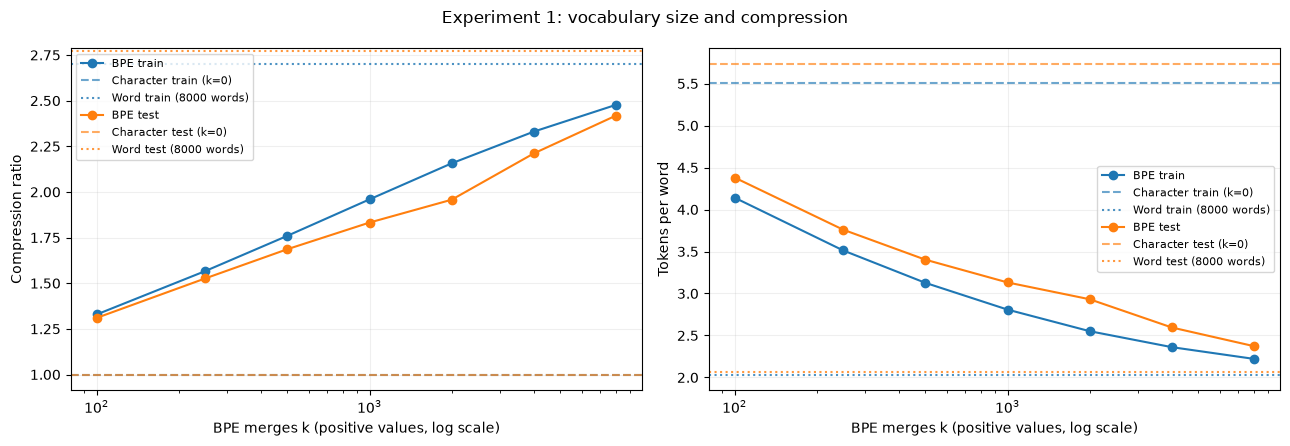

On the test split, increasing k from 0 to 8,000 changes compression from 1.000 to 2.418 characters per token and tokens per word from 5.738 to 2.373. Larger vocabularies store longer units, but these size measures alone do not establish linguistic quality.

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metric in zip(axes, ['compression ratio', 'tokens per word']):
    for split, color in [('train', 'tab:blue'), ('test', 'tab:orange')]:
        rows = a1_k_table.query("model == 'BPE' and k > 0 and split == @split")
        ax.plot(rows['k'], rows[metric], marker='o', color=color, label=f'BPE {split}')
        char_value = a1_k_table.query("model == 'BPE' and k == 0 and split == @split")[metric].iloc[0]
        word_value = a1_k_table.query("model == 'Word (8000)' and split == @split")[metric].iloc[0]
        ax.axhline(char_value, color=color, linestyle='--', alpha=.65, label=f'Character {split} (k=0)')
        ax.axhline(word_value, color=color, linestyle=':', alpha=.8, label=f'Word {split} (8000 words)')
    ax.set_xscale('log')
    ax.set(xlabel='BPE merges k (positive values, log scale)', ylabel=metric.capitalize())
    ax.grid(alpha=.2)
    ax.legend(fontsize=8)
fig.suptitle('Experiment 1: vocabulary size and compression')
fig.tight_layout()
plt.show()
a1_low = a1_k_table.query("model == 'BPE' and k == 0 and split == 'test'").iloc[0]
a1_high = a1_k_table.query("model == 'BPE' and k == 8000 and split == 'test'").iloc[0]
display(Markdown(f"On the test split, increasing k from 0 to 8,000 changes compression from {a1_low['compression ratio']:.3f} to {a1_high['compression ratio']:.3f} characters per token and tokens per word from {a1_low['tokens per word']:.3f} to {a1_high['tokens per word']:.3f}. Larger vocabularies store longer units, but these size measures alone do not establish linguistic quality."))

In [7]:
# Experiment 2: change only normalization or marker, at k=2000.
a1_normalization_rows = []
for strategy, marker in [('raw', 'end'), ('lower', 'end'), ('clean', 'end'),
                         ('split', 'end'), ('clean', 'start')]:
    record = a1_fit(2000, strategy, marker)
    half_models = a1_half_models(2000, strategy, marker)
    for split, text in [('train', a1_train_text), ('test', a1_test_text)]:
        a1_normalization_rows.append(dict(strategy=strategy, marker=marker, split=split,
            training_seconds=record['seconds'], **measure(record['tok'], text, half_models)))
a1_normalization_table = pd.DataFrame(a1_normalization_rows)
display(a1_normalization_table[['strategy', 'marker', 'split', 'training_seconds'] + a1_metric_columns].round(5))
assert (a1_normalization_table['round-trip accuracy'] == 1).all()
a1_normalization_table.to_csv(a1_result_dir / 'normalization_and_markers.csv', index=False)
a1_marker_rows = a1_normalization_table.query("strategy == 'clean' and split == 'test'")
a1_end_ratio = a1_marker_rows.query("marker == 'end'")['compression ratio'].iloc[0]
a1_start_ratio = a1_marker_rows.query("marker == 'start'")['compression ratio'].iloc[0]
display(Markdown(f"At k=2,000 on the clean test split, the suffix marker gives {a1_end_ratio:.3f} characters per token and the prefix marker gives {a1_start_ratio:.3f}. They expose different boundary-adjacent pairs to the same merge learner; every normalization/marker configuration still reconstructs its own normalized test input exactly."))

clean, start, k=2000: 0.666 s; 2000 merges; V=2043


,strategy,marker,split,training_seconds,compression ratio,tokens per word,UNK rate,round-trip accuracy,stability,stability coverage
0,raw,end,train,0.67310,2.06665,2.66245,0.0,1.0,0.65218,0.99992
1,raw,end,test,0.67310,1.87737,3.05651,0.0,1.0,0.76039,1.00000
2,lower,end,train,0.65286,2.15678,2.55119,0.0,1.0,0.60355,0.99991
3,lower,end,test,0.65286,1.95754,2.93133,0.0,1.0,0.73835,1.00000
4,clean,end,train,0.64942,2.15682,2.55112,0.0,1.0,0.60355,0.99991
5,clean,end,test,0.64942,1.95754,2.93133,0.0,1.0,0.73835,1.00000
6,split,end,train,0.46177,1.94207,2.35375,0.0,1.0,0.62478,0.99982
7,split,end,test,0.46177,1.79260,2.57715,0.0,1.0,0.78662,1.00000
8,clean,start,train,0.66628,2.18241,2.52119,0.0,1.0,0.54578,0.99991
9,clean,start,test,0.66628,2.00751,2.85837,0.0,1.0,0.73835,1.00000


At k=2,000 on the clean test split, the suffix marker gives 1.958 characters per token and the prefix marker gives 2.008. They expose different boundary-adjacent pairs to the same merge learner; every normalization/marker configuration still reconstructs its own normalized test input exactly.

,model,k,corpus,compression ratio,tokens per word,UNK rate,round-trip accuracy,stability,stability coverage
0,BPE,0.0,Shakespeare test,1.00000,5.73820,0.00000,1.00000,1.00000,1.00000
1,BPE,0.0,English prose,1.00000,5.68227,0.00856,0.73999,1.00000,0.85458
2,BPE,0.0,Python source,1.00000,12.18493,0.12018,0.26086,1.00000,0.18364
3,BPE,100.0,Shakespeare test,1.30993,4.38054,0.00000,1.00000,0.85865,1.00000
4,BPE,100.0,English prose,1.33049,4.27081,0.01138,0.73999,0.79188,0.85458
5,BPE,100.0,Python source,1.14112,10.67806,0.13713,0.26086,0.83394,0.18364
6,BPE,250.0,Shakespeare test,1.52626,3.75966,0.00000,1.00000,0.71429,1.00000
7,BPE,250.0,English prose,1.54382,3.68066,0.01321,0.73999,0.65415,0.85458
8,BPE,250.0,Python source,1.26441,9.63686,0.15195,0.26086,0.65199,0.18364
9,BPE,500.0,Shakespeare test,1.68636,3.40272,0.00000,1.00000,0.72030,1.00000


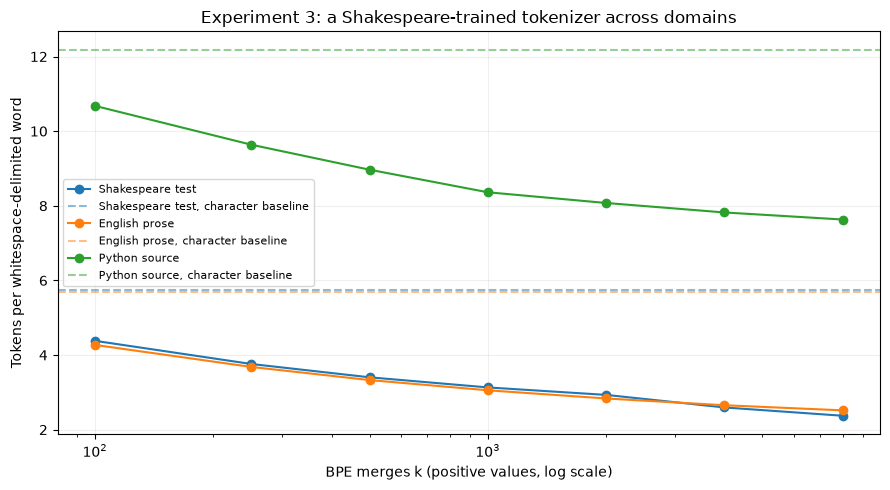

At k=8,000, **Python source** requires the most tokens per word (7.632). Word lengths, source-code syntax, unseen characters, and how well Shakespeare's learned pieces transfer all affect this measure; higher compression does not imply better meaning preservation.

In [8]:
# Experiment 3: reuse the fitted models; no fitting on either comparison corpus.
a1_domain_rows = []
for k in A1_KS:
    record = a1_registry[(k, 'clean', 'end')]
    for name, text in a1_domains.items():
        a1_domain_rows.append(dict(model='BPE', k=k, corpus=name,
            **measure(record['tok'], text, record['halves'])))
for name, text in a1_domains.items():
    a1_domain_rows.append(dict(model='Word (8000)', k=None, corpus=name,
        **measure(a1_word, text, a1_word_halves)))
a1_domain_table = pd.DataFrame(a1_domain_rows)
with pd.option_context('display.max_rows', 40):
    display(a1_domain_table[['model', 'k', 'corpus'] + a1_metric_columns].round(5))
a1_domain_table.to_csv(a1_result_dir / 'cross_domain.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 5))
for name, color in [('Shakespeare test', 'tab:blue'), ('English prose', 'tab:orange'), ('Python source', 'tab:green')]:
    rows = a1_domain_table.query("model == 'BPE' and k > 0 and corpus == @name")
    ax.plot(rows['k'], rows['tokens per word'], marker='o', color=color, label=name)
    baseline = a1_domain_table.query("model == 'BPE' and k == 0 and corpus == @name")['tokens per word'].iloc[0]
    ax.axhline(baseline, color=color, linestyle='--', alpha=.5, label=f'{name}, character baseline')
ax.set_xscale('log')
ax.set(xlabel='BPE merges k (positive values, log scale)', ylabel='Tokens per whitespace-delimited word',
       title='Experiment 3: a Shakespeare-trained tokenizer across domains')
ax.grid(alpha=.2)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
a1_at_8000 = a1_domain_table.query("model == 'BPE' and k == 8000")
a1_hardest = a1_at_8000.loc[a1_at_8000['tokens per word'].idxmax()]
display(Markdown(f"At k=8,000, **{a1_hardest['corpus']}** requires the most tokens per word ({a1_hardest['tokens per word']:.3f}). Word lengths, source-code syntax, unseen characters, and how well Shakespeare's learned pieces transfer all affect this measure; higher compression does not imply better meaning preservation."))

### Task 5

Measures, accuracy, and interpretation.

For normalized text of length $C$, emitted token count $T$, whitespace-delimited word count $W$, and unknown token count $U$:

$$\text{compression ratio}=C/T,\qquad \text{tokens per word}=T/W,\qquad \text{UNK rate}=U/T.$$

Count **every emitted token**, including preserved whitespace and a marker if it remains unmerged. Do not count synthetic boundary-marker characters toward $C$. No BOS/EOS tokens are added for these tokenizer-only experiments. Count characters after the chosen normalization, including spaces and newline separators. A lower tokens-per-word value is not automatically better when whole unknown words collapse to one `<unk>` ID.

The round-trip accuracy is the fraction of lines satisfying `decode(encode(line)) == normalize(line, strategy)`. On the Shakespeare test set it must be **1.000** for every BPE configuration. For raw normalization this is exact recovery of the original line. Unseen characters in comparison corpora cannot be recovered from `<unk>`, and the word baseline also loses unseen words; their lower round-trip accuracies are reported rather than hidden.

**Additional measure: segmentation stability.** Train tokenizers $A$ and $B$ with the same configuration on the two disjoint halves of the Shakespeare training lines. Let $E$ be the distinct word types in an evaluation corpus that both can encode without `<unk>`, and let $S_A(w)$ and $S_B(w)$ be their internal character cut positions:

$$\operatorname{stability}=\frac{1}{|E|}\sum_{w\in E}\mathbf{1}[S_A(w)=S_B(w)].$$

A high score means boundaries are insensitive to this change in training data. It does **not** establish correct morphemes, semantic understanding, or downstream model quality. The character tokenizer and the word tokenizer score 1 by construction on eligible words despite having opposite granularity, so stability is not a model-selection objective by itself. Report eligible-type counts and coverage because excluding unknown words can otherwise hide poor transfer. All earlier experiment tables include this measure and its coverage.

def measure(tokenizer, text, half_models=None):
    normalized = normalize(text, tokenizer.strategy)
    ids = tokenizer.encode(text)
    characters, words, tokens = len(normalized), len(normalized.split()), len(ids)
    unknown = ids.count(tokenizer.unk_id)
    result = {
        "characters": characters, "words": words, "tokens": tokens,
        "compression ratio": characters / tokens if tokens else float("nan"),
        "tokens per word": tokens / words if words else float("nan"),
        "unknown tokens": unknown, "UNK rate": unknown / tokens if tokens else 0.0,
        "round-trip accuracy": roundtrip_accuracy(tokenizer, text),
    }
    if half_models is not None:
        result.update(stability(half_models, text, tokenizer.strategy))
    return result

def stability(tokenizers, text, strategy):
    """Exact internal-cut agreement over distinct words encodable by both models."""
    first, second = tokenizers
    words = sorted(set(normalize(text, strategy).split()))
    eligible = [word for word in words
                if first.unk_id not in first._encode_word(word)
                and second.unk_id not in second._encode_word(word)]
    matches = sum(first.cut_positions(word) == second.cut_positions(word) for word in eligible)
    return {
        "stability": matches / len(eligible) if eligible else float("nan"),
        "stability eligible types": len(eligible),
        "stability coverage": len(eligible) / len(words) if words else float("nan"),
    }

,model,k,corpus,tokens,unknown tokens,UNK rate
0,BPE,0.0,Shakespeare test,8022,0,0.000000
1,BPE,0.0,English prose,741059,6340,0.008555
2,BPE,0.0,Python source,298738,35901,0.120176
3,BPE,100.0,Shakespeare test,6124,0,0.000000
4,BPE,100.0,English prose,556982,6340,0.011383
5,BPE,100.0,Python source,261794,35901,0.137135
6,BPE,250.0,Shakespeare test,5256,0,0.000000
7,BPE,250.0,English prose,480017,6340,0.013208
8,BPE,250.0,Python source,236267,35901,0.151951
9,BPE,500.0,Shakespeare test,4757,0,0.000000


,k,round-trip accuracy
1,0.0,1.0
3,100.0,1.0
5,250.0,1.0
7,500.0,1.0
9,1000.0,1.0
11,2000.0,1.0
13,4000.0,1.0
15,8000.0,1.0


All 400 held-out lines round-trip correctly for all eight clean BPE sizes.
Raw/lower/clean/split and both markers were also checked on all 400 lines at k=2000.


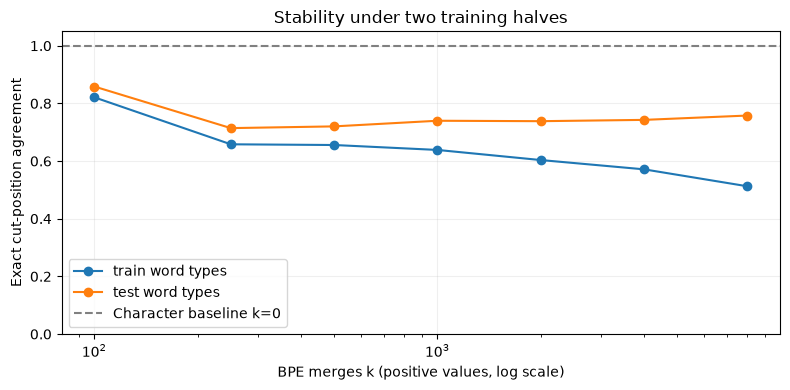

,k,stability,stability eligible types,stability coverage
1,0.0,1.00000,665,1.0
3,100.0,0.85865,665,1.0
5,250.0,0.71429,665,1.0
7,500.0,0.72030,665,1.0
9,1000.0,0.73985,665,1.0
11,2000.0,0.73835,665,1.0
13,4000.0,0.74286,665,1.0
15,8000.0,0.75789,665,1.0


Independent full-training rerun: identical merge list and vocabulary IDs.


,k,strategy,marker,training_seconds
5,0,clean,end,0.091967
6,100,clean,end,0.439514
7,250,clean,end,0.484090
8,500,clean,end,0.554352
0,1000,clean,end,0.609433
3,2000,clean,end,0.649415
9,4000,clean,end,0.780553
10,8000,clean,end,0.848123
11,2000,clean,start,0.666276
2,2000,lower,end,0.652857


Assignment 1 total: 33.99 seconds (0.57 minutes).
8,000-merge training: 0.848 seconds (<600 s).


In [9]:
display(Code(inspect.getsource(measure), language='python'))
display(Code(inspect.getsource(stability), language='python'))
# The requested UNK comparison includes every k and the word baseline on all three corpora.
a1_unknown_table = a1_domain_table[['model', 'k', 'corpus', 'tokens', 'unknown tokens', 'UNK rate']]
with pd.option_context('display.max_rows', 40):
    display(a1_unknown_table.round(6))
a1_unknown_table.to_csv(a1_result_dir / 'unknown_rates.csv', index=False)

a1_accuracy_table = a1_k_table.query("model == 'BPE' and split == 'test'")[['k', 'round-trip accuracy']]
display(a1_accuracy_table)
print('All 400 held-out lines round-trip correctly for all eight clean BPE sizes.')
print('Raw/lower/clean/split and both markers were also checked on all 400 lines at k=2000.')

fig, ax = plt.subplots(figsize=(8, 4))
for split in ['train', 'test']:
    rows = a1_k_table.query("model == 'BPE' and k > 0 and split == @split")
    ax.plot(rows['k'], rows['stability'], marker='o', label=f'{split} word types')
ax.axhline(1, linestyle='--', color='gray', label='Character baseline k=0')
ax.set_xscale('log')
ax.set(xlabel='BPE merges k (positive values, log scale)', ylabel='Exact cut-position agreement',
       title='Stability under two training halves', ylim=(0, 1.05))
ax.legend()
ax.grid(alpha=.2)
fig.tight_layout()
plt.show()
a1_stability_details = a1_k_table.query("model == 'BPE' and split == 'test'")[
    ['k', 'stability', 'stability eligible types', 'stability coverage']]
display(a1_stability_details.round(5))

# Verify determinism again on the complete training split.
a1_repeat = BPETokenizer(1000).train(a1_train_text)
assert a1_repeat.merges == a1_main['tok'].merges
assert a1_repeat.vocab == a1_main['tok'].vocab
print('Independent full-training rerun: identical merge list and vocabulary IDs.')
a1_timing_rows = [dict(k=k, strategy=strategy, marker=marker, training_seconds=record['seconds'])
                  for (k, strategy, marker), record in a1_registry.items()]
a1_timing_table = pd.DataFrame(a1_timing_rows).sort_values(['strategy', 'marker', 'k'])
display(a1_timing_table)
a1_timing_table.to_csv(a1_result_dir / 'training_times.csv', index=False)
A1_SECONDS = time.perf_counter() - A1_START
a1_runtime = dict(seconds=A1_SECONDS, seed=A1_SEED, machine=platform.platform(),
                  python=platform.python_version(), device='CPU',
                  k8000_seconds=a1_registry[(8000, 'clean', 'end')]['seconds'])
(a1_result_dir / 'runtime.json').write_text(json.dumps(a1_runtime, indent=2))
print(f'Assignment 1 total: {A1_SECONDS:.2f} seconds ({A1_SECONDS / 60:.2f} minutes).')
print(f"8,000-merge training: {a1_runtime['k8000_seconds']:.3f} seconds (<600 s).")